
# **Exploratory Data Analysis - EDA**

<!-- ## Mục lục
- [1. Giới thiệu tổng quan về Bộ dữ liệu](#1-giới-thiệu-tổng-quan-về-bộ-dữ-liệu)
- [2. Cài đặt và khai báo Thư viện & Gói phụ thuộc](#phan-3)
- [3. Tiền xử lí](#phan-3)
- [4. Hướng dẫn chạy notebook](#4-hướng-dẫn-chạy-notebook)
- [5. Phân công thành viên](#5-phân-công-thành-viên)
- [6. Link dữ liệu Google Drive](#6-link-dữ-liệu-google-drive) -->



## 1. Giới thiệu **tổng quan** về Bộ dữ liệu

### 1.1. Chủ đề dữ liệu
Bộ dữ liệu **Amazon Products Sales Dataset 42K+ Items - 2025** chứa thông tin chi tiết của hơn **42.000 sản phẩm điện tử** được bán trên nền tảng thương mại điện tử Amazon, bao gồm **17 đặc trưng (features)** chính:

- **Thông tin định danh:** Tên sản phẩm (Title), URL sản phẩm, URL hình ảnh.
- **Chỉ số đánh giá:** Điểm đánh giá trung bình (Rating), Tổng số lượt đánh giá (Number of reviews).
- **Thông tin bán hàng:** Số lượng mua trong tháng qua (Bought in last month), Giá hiện tại/giá sau giảm (Discounted price), Giá gốc (Original listed price).
- **Phân loại trạng thái:** Nhãn Bán chạy nhất (Best Seller), Tài trợ (Sponsored), Có mã giảm giá (Coupon), Tùy chọn mua ngay (Buy Box).

Đây là dạng dữ liệu **bảng (tabular data)** đặc trưng trong lĩnh vực e-commerce. Nó bao gồm sự pha trộn đa dạng giữa biến số học (numerical), phân loại (categorical) và biến boolean (đúng/sai), rất lý tưởng cho các bài toán phân tích thống kê và khám phá dữ liệu (EDA).

### 1.2. Nguồn gốc dữ liệu
- **Nền tảng**: Kaggle  
- **URL đầy đủ**: [https://www.kaggle.com/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025](https://www.kaggle.com/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025)  
- **Người tải lên Kaggle**: IKRAM SHERAZI (ikramshah512)  
- **Nguồn gốc ban đầu**: Trích xuất trực tiếp từ giao diện hiển thị của nền tảng Amazon.  
- **Ngày cập nhật trên Kaggle**: Quý 3 năm 2025.

### 1.3. Giấy phép sử dụng
Dataset được cung cấp theo giấy phép **CC BY-NC 4.0 (Creative Commons Attribution-NonCommercial 4.0 International)**.  

→ **Hoàn toàn được phép sử dụng, thay đổi và chia sẻ cho mục đích phi thương mại** (như học tập, nghiên cứu, đồ án môn học).  \
→ Yêu cầu duy nhất là cần ghi rõ nguồn (attribution) khi sử dụng. \
Nhóm đã tuân thủ đầy đủ quy định này.

### 1.4. Phương pháp thu thập dữ liệu
Dữ liệu được thu thập thông qua kỹ thuật **Web Scraping** tự động từ các trang danh mục sản phẩm của Amazon. Để tối ưu hóa quá trình phân tích thống kê chuyên sâu theo yêu cầu của đồ án, nhóm quyết định sử dụng phiên bản dữ liệu đã qua tiền xử lý định dạng cơ bản (`amazon_products_sales_data_cleaned.csv`). 

Phiên bản này đã được chuẩn hóa các lỗi chuỗi ký tự (như ký hiệu tiền tệ, văn bản dính liền số), nhưng **vẫn giữ nguyên bản chất missing values** của dữ liệu thực tế (ví dụ: sản phẩm không có đánh giá, không có giá gốc do không chạy khuyến mãi), tạo tiền đề cho các bước phân tích cơ chế thiếu hụt dữ liệu (MCAR/MAR/MNAR) ở phần sau.

### 1.5. Lý do chọn bộ dữ liệu này
Bộ dữ liệu được chọn vì **đáp ứng nghiêm ngặt và vượt trội các tiêu chí bắt buộc của Mục 2.2.1**:

- **Kích thước tập dữ liệu:** Đạt hơn 42.000 bản ghi (vượt xa mức tối thiểu 10.000 record).
- **Số lượng thuộc tính:** Gồm 17 thuộc tính (vượt mức tối thiểu 10 thuộc tính).
- **Đa dạng kiểu dữ liệu:** Có sự kết hợp rõ rệt giữa biến số liên tục (Giá tiền, Số lượng đánh giá) và biến phân loại/boolean (Best Seller, Sponsored, Category).
- **Tỉ lệ giá trị thiếu :** Tập dữ liệu duy trì tỷ lệ giá trị thiếu $\ge$ 5% ở nhiều thuộc tính quan trọng (như giá trị giảm giá, số lượng mua tháng qua, hoặc điểm đánh giá đối với các sản phẩm mới).
- **Tiềm năng ứng dụng :** Các đặc trưng về giá, hạng mục và đánh giá cung cấp nền tảng vững chắc để xây dựng các mô hình dự đoán (VD: dự đoán khả năng một sản phẩm trở thành Best Seller hoặc dự đoán phân khúc giá).

**Kết luận:**
Bộ dữ liệu này là một lựa chọn tối ưu, không chỉ thỏa mãn các rào cản kỹ thuật đầu vào mà còn cung cấp đủ độ phức tạp thống kê để áp dụng trọn vẹn quy trình EDA chuyên sâu.



## 2. Cài đặt và khai báo Thư viện & Gói phụ thuộc

In [3]:
import re
import warnings
warnings.filterwarnings('ignore') 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer

file_path = '../data/raw/amazon_products_sales_data_cleaned.csv'
df = pd.read_csv(file_path)
df.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


## 3. Kiểm tra phân phối

**3.1. Mục đích và Cơ sở lý thuyết:**
Nhiều thuật toán Machine Learning hoạt động tối ưu nhất khi dữ liệu đầu vào tuân theo phân phối chuẩn (Normal Distribution). Việc kiểm tra phân phối giúp định hướng chính xác phương pháp chuẩn hóa dữ liệu. Nhóm sử dụng kiểm định giả thuyết thống kê với mức ý nghĩa $\alpha = 0.05$:
* **Giả thuyết không ($H_0$):** Thuộc tính dữ liệu tuân theo phân phối chuẩn.
* **Đối thuyết ($H_a$):** Thuộc tính dữ liệu KHÔNG tuân theo phân phối chuẩn.

**3.2. Chi tiết các phương pháp kiểm định:**

Dựa trên kích thước mẫu ($n$), nhóm áp dụng hai thuật toán kiểm định sau:

**Kiểm định Shapiro-Wilk (Áp dụng khi $n \le 5000$):**
Thuật toán này so sánh các giá trị của mẫu (đã được sắp xếp) với các giá trị kỳ vọng của một phân phối chuẩn chuẩn hóa. Thống kê $W$ được tính bằng công thức:

$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

Trong đó:
* $x_{(i)}$ là giá trị thứ $i$ của mẫu sau khi đã sắp xếp tăng dần.
* $\bar{x}$ là giá trị trung bình của mẫu.
* $a_i$ là các hằng số được tính toán từ ma trận hiệp phương sai của các thống kê thứ tự từ một phân phối chuẩn.
* **Ý nghĩa:** Giá trị $W$ luôn nằm trong khoảng $[0, 1]$. Nếu $W$ càng gần 1, dữ liệu càng có khả năng tuân theo phân phối chuẩn. 

**Kiểm định D’Agostino-Pearson (Áp dụng khi $n > 5000$):**
Shapiro-Wilk thường quá nhạy cảm với cỡ mẫu lớn (dễ dàng bác bỏ $H_0$ dù dữ liệu chỉ lệch một chút xíu). Do đó, với tập dữ liệu lớn, D’Agostino-Pearson ($K^2$ test) được ưu tiên. Kiểm định này kết hợp cả độ lệch (Skewness) và độ nhọn (Kurtosis) của dữ liệu:

$$K^2 = Z_1(g_1)^2 + Z_2(g_2)^2$$

Trong đó:
* $g_1$ là độ lệch (sample skewness) và $Z_1(g_1)$ là phép biến đổi để nó tuân theo phân phối chuẩn tiệm cận.
* $g_2$ là độ nhọn (sample kurtosis) và $Z_2(g_2)$ là phép biến đổi tương ứng.
* **Ý nghĩa:** Dưới giả thuyết $H_0$, thống kê $K^2$ xấp xỉ tuân theo phân phối Chi-bình phương với 2 bậc tự do ($\chi^2_2$). Nếu giá trị $K^2$ quá lớn, ta bác bỏ giả thuyết dữ liệu có phân phối chuẩn.

**3.3. Tiêu chí kết luận và chọn Scaler:**
* Nếu $p\text{-value} > \alpha$: Không đủ bằng chứng bác bỏ $H_0 \rightarrow$ Phân phối chuẩn $\rightarrow$ Đề xuất dùng `StandardScaler`.
* Nếu $p\text{-value} \le \alpha$: Bác bỏ $H_0 \rightarrow$ Phân phối không chuẩn $\rightarrow$ Đề xuất dùng `MinMaxScaler` hoặc `RobustScaler`.


In [8]:
normality_res = []

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    data = df[col].dropna()
    n = len(data)

    if n == 0:
        continue
    stat, p_val = None, None
    test_name = ""

    if n <= 5000:
        stat, p_value = stats.shapiro(data)
        test_name = "Shapiro-Wilk"
    else:
        stat, p_value = stats.normaltest(data)
        test_name = "D'Agostino-Pearson"
    is_normal = "Chuẩn" if p_value > 0.05 else "Không chuẩn"
    skew_val = data.skew()
    normality_res.append({
        'Thuộc tính': col,
        'Cỡ mẫu (n)': n,
        'Kiểm định': test_name,
        'Statistic': round(stat, 4),
        'P-value': p_value,
        'Phân phối': is_normal,
        'Skewness': round(skew_val, 2),
    })

df_normality = pd.DataFrame(normality_res)
display(df_normality.style.format({'P-value': '{:.4e}'}).set_caption("BẢNG TỔNG HỢP KIỂM ĐỊNH PHÂN PHỐI VÀ ĐỀ XUẤT CHUẨN HÓA"))

,Thuộc tính,Cỡ mẫu (n),Kiểm định,Statistic,P-value,Phân phối,Skewness
0,product_rating,41651,D'Agostino-Pearson,16927.702100,0.0000e+00,Không chuẩn,-1.840000
1,total_reviews,41651,D'Agostino-Pearson,99590.224900,0.0000e+00,Không chuẩn,24.340000
2,purchased_last_month,32164,D'Agostino-Pearson,51609.162900,0.0000e+00,Không chuẩn,10.720000
3,discounted_price,40613,D'Agostino-Pearson,36502.205500,0.0000e+00,Không chuẩn,4.430000
4,original_price,40613,D'Agostino-Pearson,35280.474500,0.0000e+00,Không chuẩn,4.260000
5,discount_percentage,40613,D'Agostino-Pearson,19589.555700,0.0000e+00,Không chuẩn,2.370000


**3.4. Phân tích kết quả:**

Dựa trên kết quả từ bảng tổng hợp thống kê, nhóm rút ra các luận điểm phân tích sâu như sau:

* **Độ tin cậy của kiểm định:** Với cỡ mẫu ($n$) rất lớn sau khi loại bỏ giá trị khuyết 
(dao động từ $32,164$ đến $41,651$ bản ghi), thuật toán đã tự động định tuyến sang sử dụng 
kiểm định **D'Agostino-Pearson**. Sự lựa chọn này phù hợp hơn Shapiro-Wilk vì Shapiro-Wilk 
có xu hướng bác bỏ $H_0$ quá dễ dàng trên mẫu lớn (sensitivity quá cao dẫn đến Type I error 
tăng), trong khi D'Agostino-Pearson dựa trên skewness và kurtosis — phản ánh đúng bản chất 
hình dạng phân phối.

* **Bác bỏ giả thuyết không ($H_0$):** Toàn bộ 6/6 thuộc tính số học đều trả về giá trị 
thống kê ($K^2$) cực kỳ lớn (từ xấp xỉ 16,928 đến hơn 99,590) và $p\text{-value} \approx 0$ 
(nhỏ hơn mọi ngưỡng ý nghĩa thực tế, dưới ngưỡng biểu diễn floating-point của Python 
$\approx 10^{-308}$). Do $p\text{-value} \ll \alpha = 0.05$, ta **bác bỏ $H_0$** cho tất cả 
các biến. Kết luận: **Không có bất kỳ thuộc tính nào tuân theo phân phối chuẩn.**

* **Phân tích mức độ lệch (Skewness):** Dù tất cả đều "không chuẩn", mức độ vi phạm 
rất khác nhau giữa các biến:
    * **Lệch cực mạnh (|skew| > 10):** `total_reviews` (skew = 24.34) và 
    `purchased_last_month` (skew = 10.72) — phân phối đuôi dài (Long-tail) điển hình 
    của dữ liệu thương mại điện tử, phần lớn sản phẩm có lượt tương tác thấp trong khi 
    một số rất ít sản phẩm "Best Seller" gánh hàng vạn lượt mua/đánh giá.
    * **Lệch mạnh (2 < |skew| < 5):** `discounted_price` (4.43), `original_price` (4.26) 
    và `discount_percentage` (2.37) — rổ hàng hóa chứa chủ yếu sản phẩm phổ thông 
    giá bình dân, xen lẫn một số ít thiết bị giá trị cao kéo đuôi phải.
    * **Lệch trái vừa (|skew| < 2):** `product_rating` (skew = −1.84) — biến duy nhất 
    lệch trái, đa số sản phẩm có rating 4.0–5.0 do selection bias trên Amazon 
    (sản phẩm rating thấp ít xuất hiện trong kết quả tìm kiếm).

* **Đề xuất chiến lược chuẩn hóa (Scaling) dựa trên p-value và skewness:**

| Kết quả kiểm định | Skewness | Biến | Đề xuất Scaling |
|-------------------|----------|------|-----------------|
| Không chuẩn ($p \approx 0$) | skew > 2 | `total_reviews`, `purchased_last_month`, `discounted_price`, `original_price`, `discount_percentage` | **RobustScaler** |
| Không chuẩn ($p \approx 0$) | skew < 2 | `product_rating` | **RobustScaler hoặc MinMaxScaler** |


  - **RobustScaler**: sử dụng Median và IQR thay vì Mean và Std, robust với outlier và đuôi nặng — phù hợp cho 5 biến lệch mạnh.
  - **RobustScaler hoặc MinMaxScaler**: `product_rating` có phân phối gần chuẩn nhất (skew = −1.84), ít outlier — cả hai phương pháp đều khả dụng.



**3.5. Trực quan hóa**

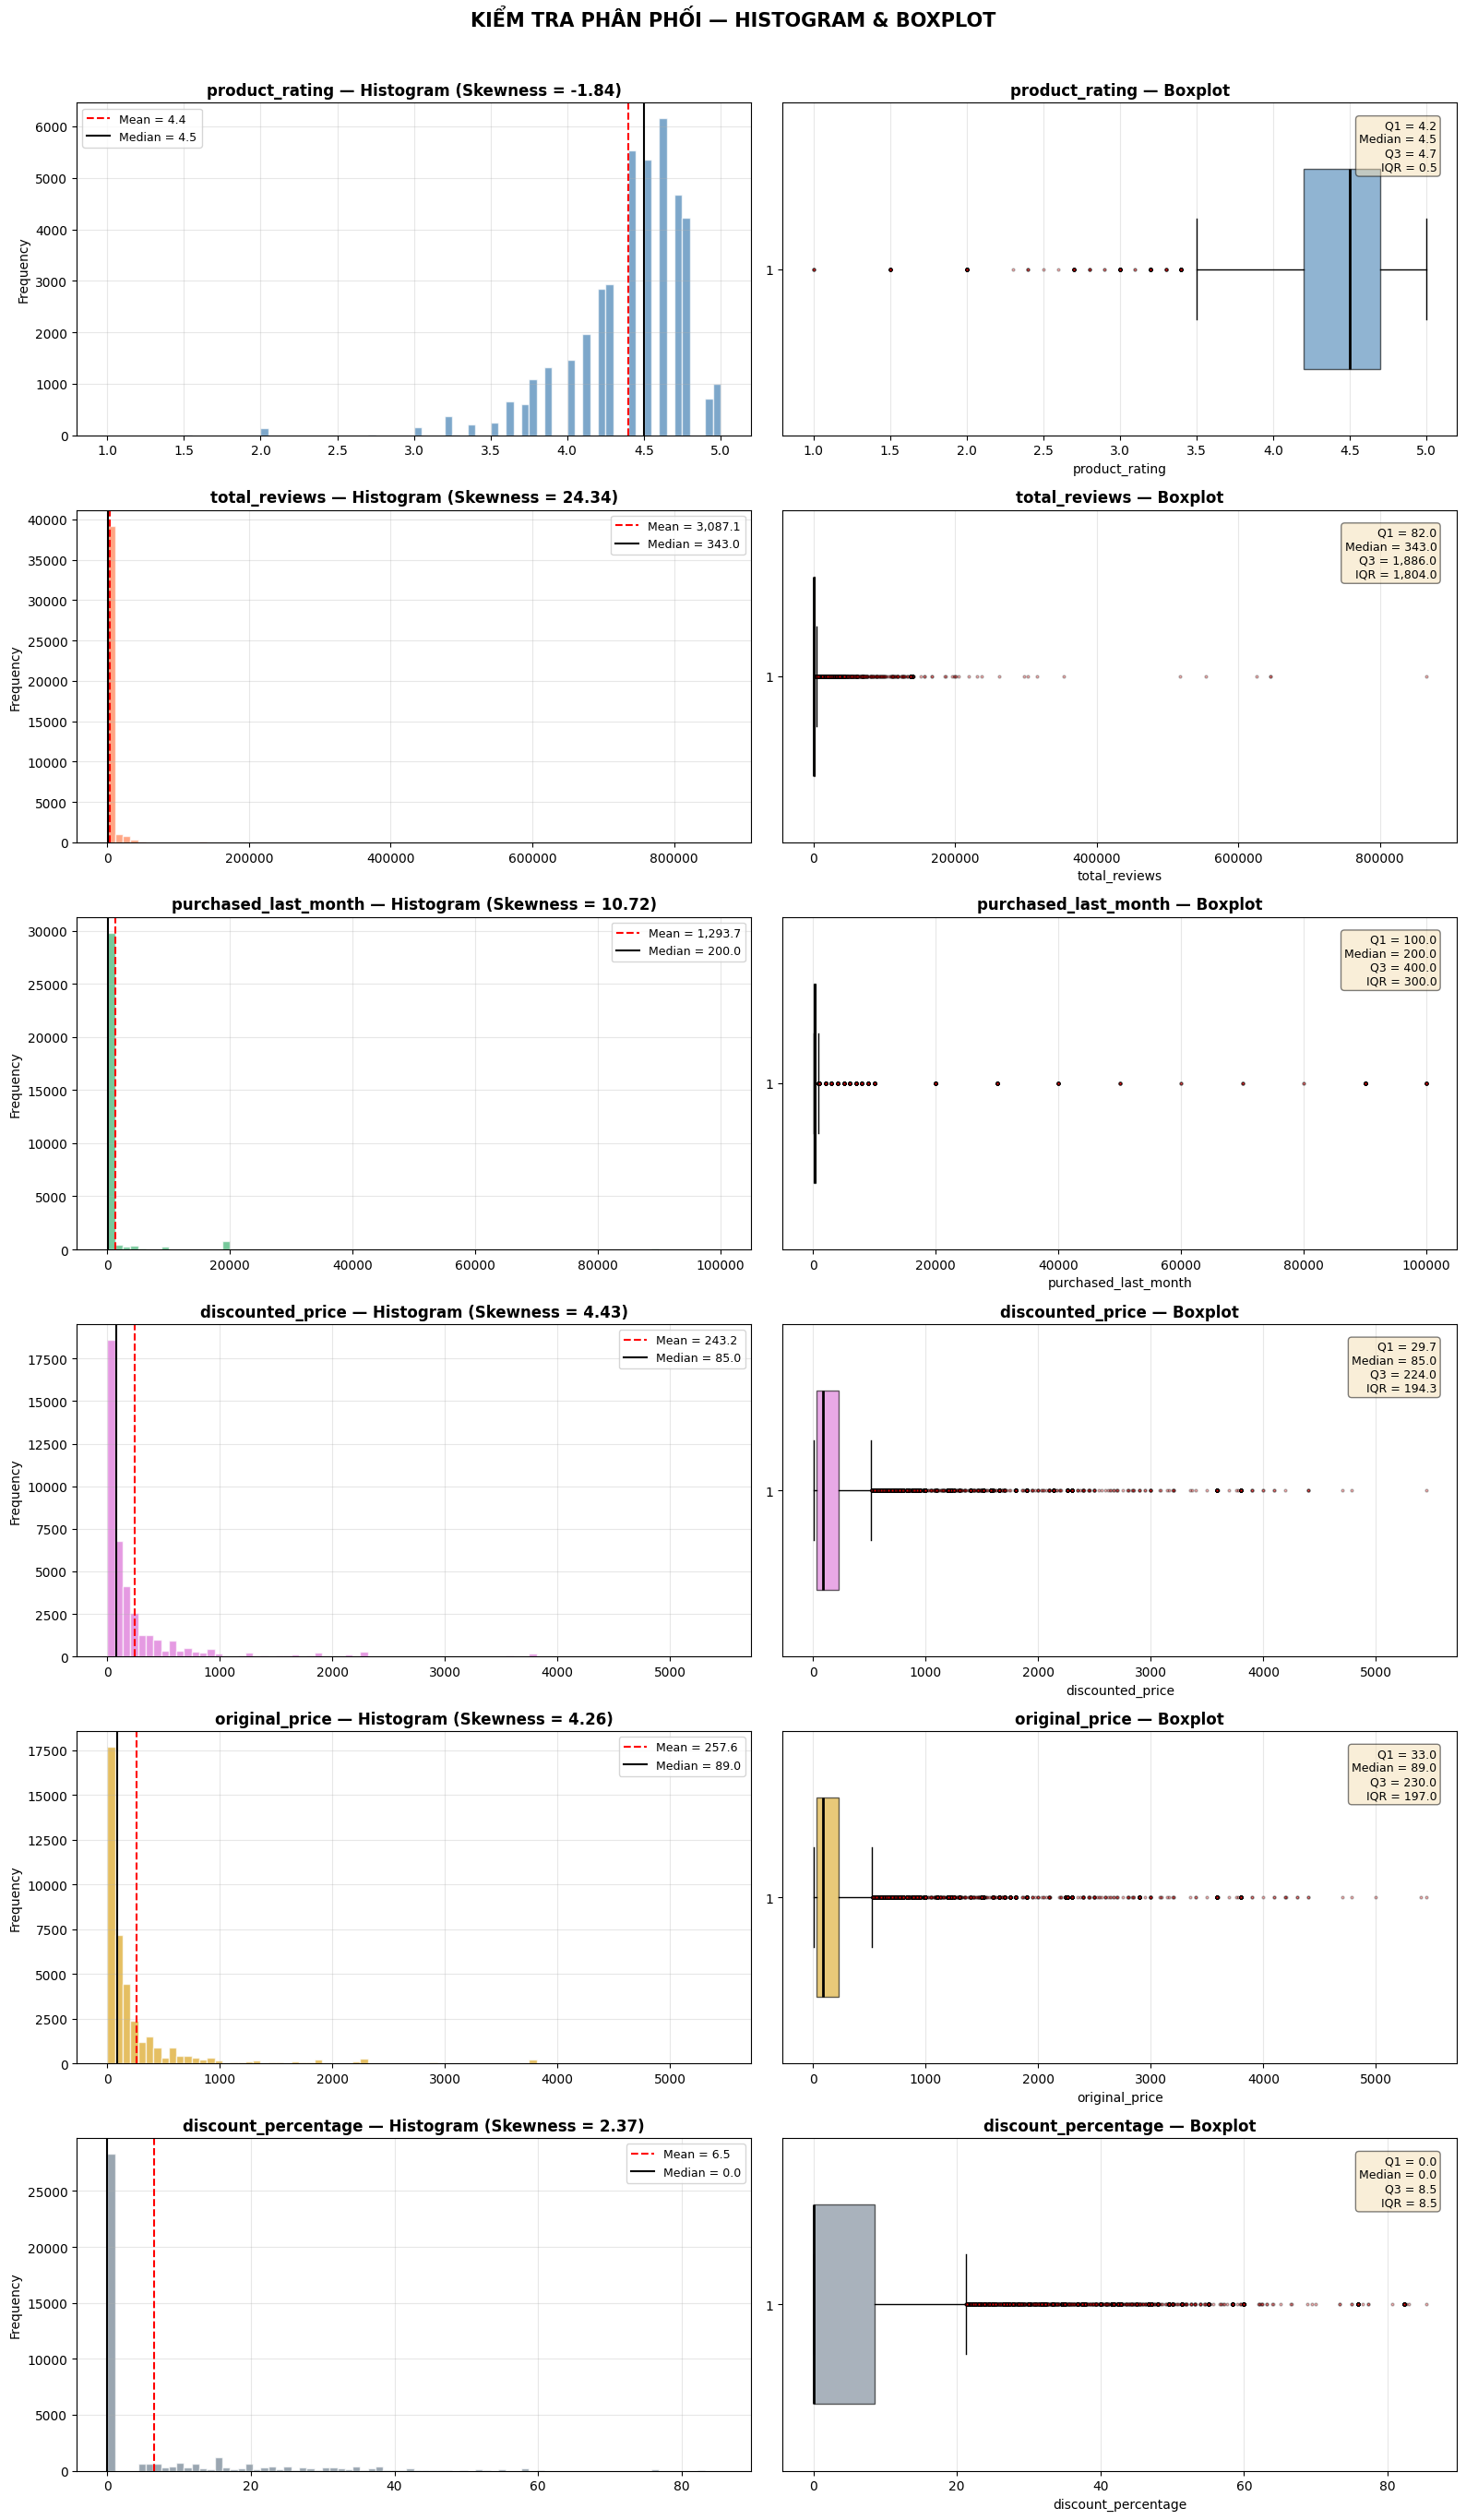

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(numeric_cols)

colors = ['steelblue', 'coral', 'mediumseagreen', 
          'orchid', 'goldenrod', 'slategray']

fig, axes = plt.subplots(n_cols, 2, figsize=(16, 4.5 * n_cols))

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    skew_val = data.skew()
    color = colors[i % len(colors)]
    
    axes[i, 0].hist(data, bins=80, color=color, edgecolor='white', alpha=0.7)
    axes[i, 0].axvline(data.mean(), color='red', linestyle='--', lw=1.5,
                        label=f'Mean = {data.mean():,.1f}')
    axes[i, 0].axvline(data.median(), color='black', linestyle='-', lw=1.5,
                        label=f'Median = {data.median():,.1f}')
    axes[i, 0].set_title(f'{col} — Histogram (Skewness = {skew_val:.2f})',
                          fontweight='bold', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend(fontsize=9)
    axes[i, 0].grid(alpha=0.3)
    

    bp = axes[i, 1].boxplot(data, vert=False, widths=0.6,
                             patch_artist=True,
                             boxprops=dict(facecolor=color, alpha=0.6),
                             medianprops=dict(color='black', linewidth=2),
                             flierprops=dict(marker='o', markersize=2, 
                                            alpha=0.3, markerfacecolor='red'))
    axes[i, 1].set_title(f'{col} — Boxplot',
                          fontweight='bold', fontsize=12)
    axes[i, 1].set_xlabel(col)
    

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    stats_text = (f'Q1 = {q1:,.1f}\n'
                  f'Median = {data.median():,.1f}\n'
                  f'Q3 = {q3:,.1f}\n'
                  f'IQR = {iqr:,.1f}')
    axes[i, 1].text(0.97, 0.95, stats_text,
                     transform=axes[i, 1].transAxes, fontsize=9,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[i, 1].grid(alpha=0.3, axis='x')

plt.suptitle('KIỂM TRA PHÂN PHỐI — HISTOGRAM & BOXPLOT',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Phân tích tương quan đa biến

**4.1. Mục đích và Cơ sở lý thuyết:**
Phân tích tương quan giúp đánh giá mức độ và chiều hướng mối quan hệ giữa các biến số học. Việc phát hiện các cặp biến độc lập có tương quan quá mạnh là bắt buộc, vì hiện tượng này làm sai lệch trọng số của các thuật toán học máy tuyến tính (như Linear Regression, Logistic Regression), dẫn đến hiện tượng Overfitting và làm giảm khả năng diễn giải của mô hình.

Nhóm sử dụng hai phương pháp đo lường tương quan :

**Hệ số tương quan Pearson ($r$):**
Đánh giá mức độ quan hệ **tuyến tính** giữa hai biến liên tục. Tuy nhiên, Pearson rất nhạy cảm với các giá trị ngoại lai (outliers) và giả định dữ liệu có phân phối chuẩn.
$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

**Hệ số tương quan hạng Spearman ($\rho$):**
Đánh giá mức độ quan hệ **đơn điệu** (monotonic) dựa trên thứ hạng (rank) của dữ liệu thay vì giá trị thực. Phương pháp này phi tham số, cực kỳ mạnh mẽ trước các giá trị ngoại lai và không đòi hỏi dữ liệu phải có phân phối chuẩn.
$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$
*(Trong đó $d_i$ là độ chênh lệch thứ hạng giữa từng cặp quan sát tương ứng).*

**4.2. Tiêu chí xác định Đa cộng tuyến:**
* Xét ma trận tương quan, các cặp biến có giá trị tuyệt đối $|r| > 0.9$ (hoặc $|\rho| > 0.9$) được xem là có hiện tượng đa cộng tuyến mạnh.
* Đề xuất xử lý: Cần loại bỏ một trong hai biến hoặc sử dụng các kỹ thuật giảm chiều dữ liệu (như PCA) để giữ tính ổn định cho không gian đặc trưng.

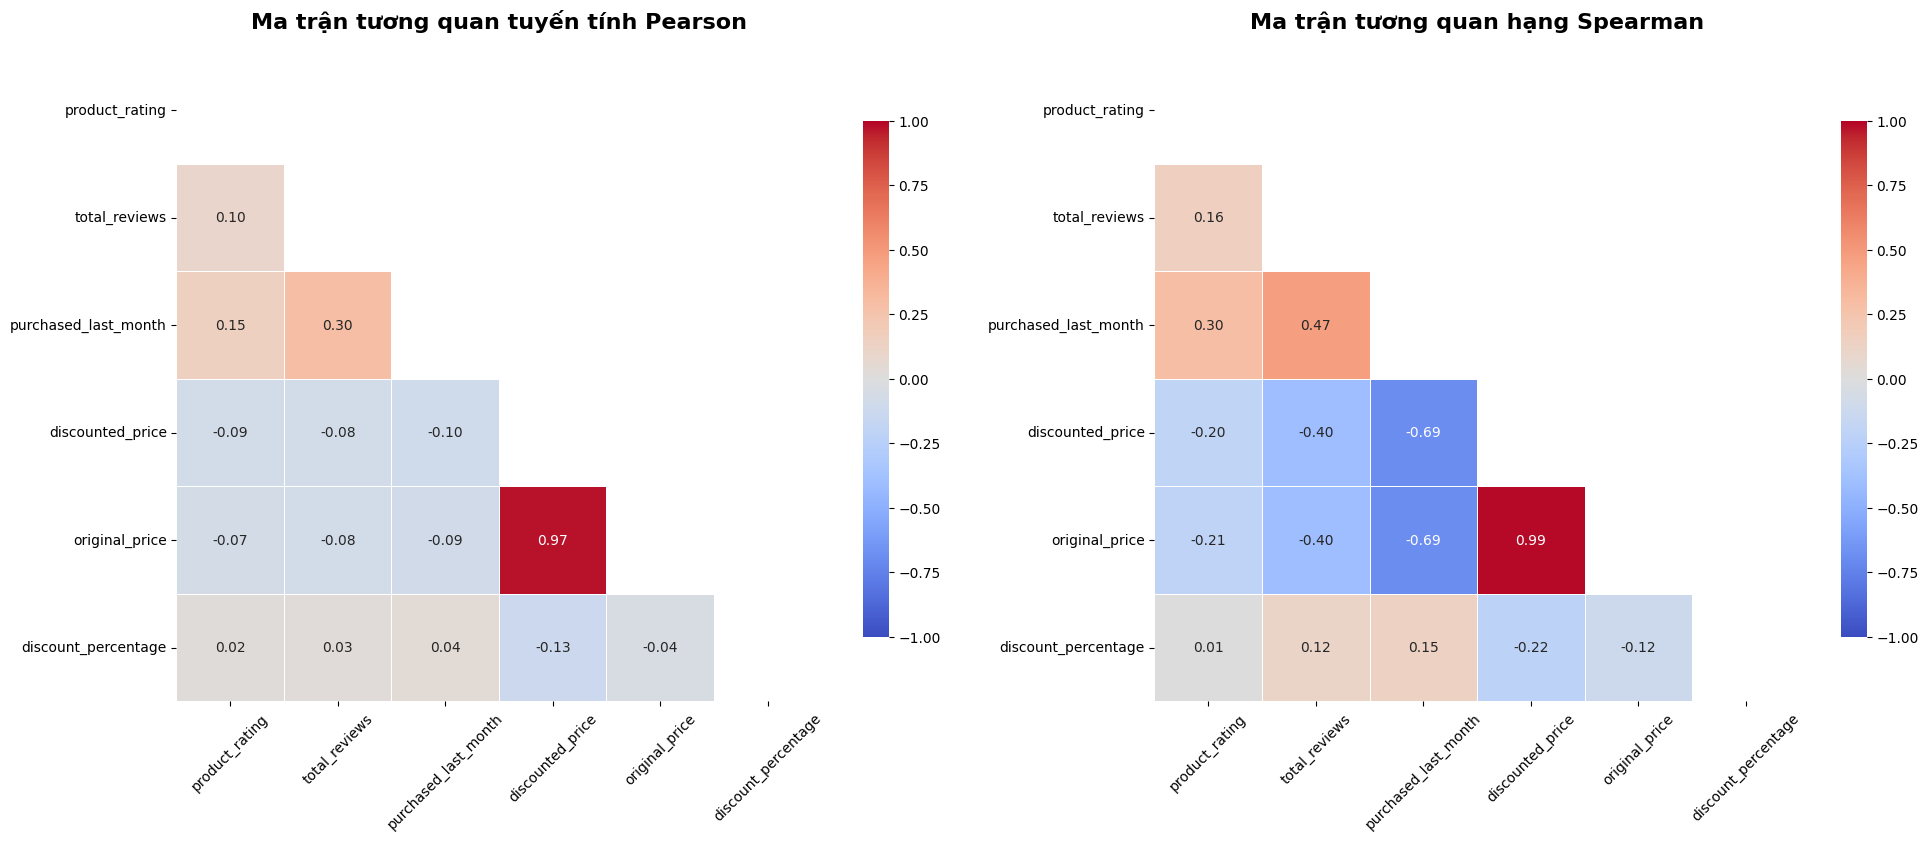

CÁC CẶP THUỘC TÍNH CÓ HIỆN TƯỢNG ĐA CỘNG TUYẾN MẠNH (|r| > 0.9):
-----------------------------------------------------------------
- [Pearson] original_price và discounted_price: 0.9746
- [Spearman] original_price và discounted_price: 0.9920


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr_pearson = numeric_df.corr(method='pearson')
corr_spearman = numeric_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

def plot_heatmap(corr_matrix, ax, title):
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
                cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.tick_params(axis='x', rotation=45)

plot_heatmap(corr_pearson, axes[0], "Ma trận tương quan tuyến tính Pearson")
plot_heatmap(corr_spearman, axes[1], "Ma trận tương quan hạng Spearman")
plt.tight_layout()
plt.show()

print("CÁC CẶP THUỘC TÍNH CÓ HIỆN TƯỢNG ĐA CỘNG TUYẾN MẠNH (|r| > 0.9):")
print("-" * 65)

def find_high_correlation(corr_matrix, method_name):
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > 0.9:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
                
    if high_corr:
        for var1, var2, val in high_corr:
            print(f"- [{method_name}] {var1} và {var2}: {val:.4f}")
    else:
        print(f"- [{method_name}] Không phát hiện cặp nào.")

find_high_correlation(corr_pearson, "Pearson")
find_high_correlation(corr_spearman, "Spearman")

**4.3. Phân tích kết quả và đề xuất xử lý:**

Từ hai biểu đồ Heatmap, nhóm rút ra các quan sát quan trọng sau:

**Sự chênh lệch giữa Pearson và Spearman — vai trò của outlier và phi tuyến:**

Quan sát cặp **`purchased_last_month`** và **`discounted_price`**:
* **Pearson ($r$):** $-0.10$ (tương quan cực kỳ yếu).
* **Spearman ($\rho$):** $-0.69$ (tương quan nghịch mạnh).

Sự khác biệt này xuất phát từ hai nguyên nhân: 

(1) Outlier — Pearson sử dụng giá trị thô nên rất nhạy cảm với các giá trị cực đoan (sản phẩm giá rất cao hoặc lượng mua cực lớn), chỉ cần vài điểm ngoại lai là kéo hệ số về gần 0.

(2) Quan hệ phi tuyến đơn điệu — khi giá giảm, lượng mua tăng theo quy luật 
phi tuyến (logarit/mũ) chứ không tăng đều, Spearman dựa trên rank nên bắt được 
xu hướng này trong khi Pearson thì không. Kết quả này cũng nhất quán với phân tích 
phân phối ở phần 3: dữ liệu chứa nhiều outlier và phân phối lệch phải mạnh. 
Do đó, **Spearman đáng tin cậy hơn Pearson** cho tập dữ liệu này.

**Các cặp tương quan đáng chú ý (Spearman):**

| Cặp biến | Pearson | Spearman | Nhận xét |
|----------|---------|----------|----------|
| `original_price` — `discounted_price` | 0.97 | 0.99 | **Đa cộng tuyến** — gần như bản sao |
| `discounted_price` — `purchased_last_month` | −0.10 | −0.69 | Giá thấp → bán nhiều hơn (phi tuyến) |
| `total_reviews` — `purchased_last_month` | 0.30 | 0.47 | Bán nhiều → nhiều review (hợp lý) |
| `original_price` — `purchased_last_month` | 0.09 | −0.69 | Pearson bị outlier che lấp hoàn toàn |
| `discount_percentage` — các biến khác | ≈ 0 | ≈ 0 | Tương quan rất thấp, biến độc lập |

**Xác nhận hiện tượng Đa cộng tuyến:**

Cặp **`original_price`** và **`discounted_price`** đạt hệ số tương quan 
**0.97** (Pearson) và **0.99** (Spearman) — hai biến gần như là bản sao 
về mặt thông tin. Nếu giữ cả hai trong các mô hình tuyến tính 
(Linear Regression, Logistic Regression), ma trận hiệp phương sai sẽ bị 
suy biến, khiến mô hình không xác định được trọng số chính xác cho từng biến.

#### Đề xuất xử lý

1. **Loại bỏ `original_price`** ở bước tiền xử lý: vì `discounted_price` 
   là giá thực tế khách hàng chi trả, mang giá trị dự báo cao hơn cho lượng mua.
2. **Giữ `discounted_price`**: tương quan nghịch mạnh với target (Spearman = −0.69), 
   là feature quan trọng.
3. **Giữ `discount_percentage`**: dù được tính từ hai biến giá, nhưng tương quan 
   gần 0 với các biến còn lại — mang thông tin độc lập về "mức độ khuyến mãi" 
   mà không gây đa cộng tuyến.


## 5. Phân tích giá trị thiếu

**5.1. Mục đích và Cơ sở lý thuyết:**
Việc hiểu rõ tại sao dữ liệu bị thiếu giúp lựa chọn phương pháp xử lý (xóa bỏ hay điền khuyết) một cách khoa học, tránh gây sai lệch cho mô hình. 

**5.2. Phân loại cơ chế thiếu dữ liệu:** 
* **MCAR (Missing Completely At Random):** Dữ liệu thiếu hoàn toàn ngẫu nhiên. Xác suất một giá trị bị thiếu không phụ thuộc vào bất kỳ biến nào khác.
* **MAR (Missing At Random):** Dữ liệu thiếu ngẫu nhiên. Xác suất thiếu phụ thuộc vào các biến đã quan sát được nhưng không phụ thuộc vào chính giá trị bị thiếu đó.
* **MNAR (Missing Not At Random):** Dữ liệu thiếu không ngẫu nhiên. Xác suất thiếu phụ thuộc vào chính giá trị của biến bị thiếu.

**5.3. Kiểm định Little’s MCAR Test:**
Đây là kiểm định giả thuyết thống kê để xác định xem dữ liệu có thuộc cơ chế MCAR hay không:
* **Giả thuyết $H_0$:** Dữ liệu bị thiếu hoàn toàn ngẫu nhiên (MCAR).
* **Đối thuyết $H_a$:** Dữ liệu không phải MCAR (có thể là MAR hoặc MNAR).

Thống kê kiểm định dựa trên khoảng cách Mahalanobis giữa trung bình các nhóm có cùng cấu trúc thiếu:
$$d^2 = \sum_{j=1}^{J} n_j (\bar{x}_j - \bar{x}_{grand})' \Sigma^{-1} (\bar{x}_j - \bar{x}_{grand})$$
*Trong đó $d^2$ xấp xỉ phân phối Chi-bình phương ($\chi^2$). Nếu $p\text{-value} < 0.05$, ta bác bỏ $H_0$.*

**Trực quan hóa ma trận thiếu dữ liệu**

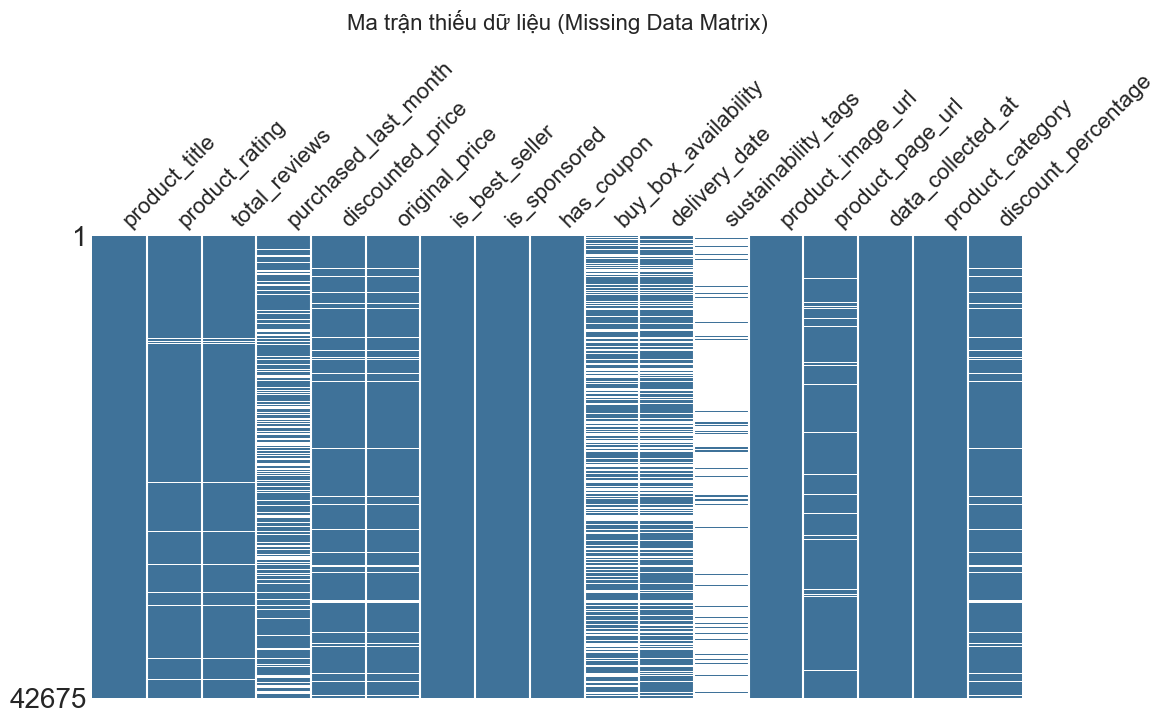

In [25]:
msno.matrix(df, figsize=(12, 6), color=(0.25, 0.45, 0.6), sparkline=False)
plt.title("Ma trận thiếu dữ liệu (Missing Data Matrix)", fontsize=16, pad=20)
plt.show()

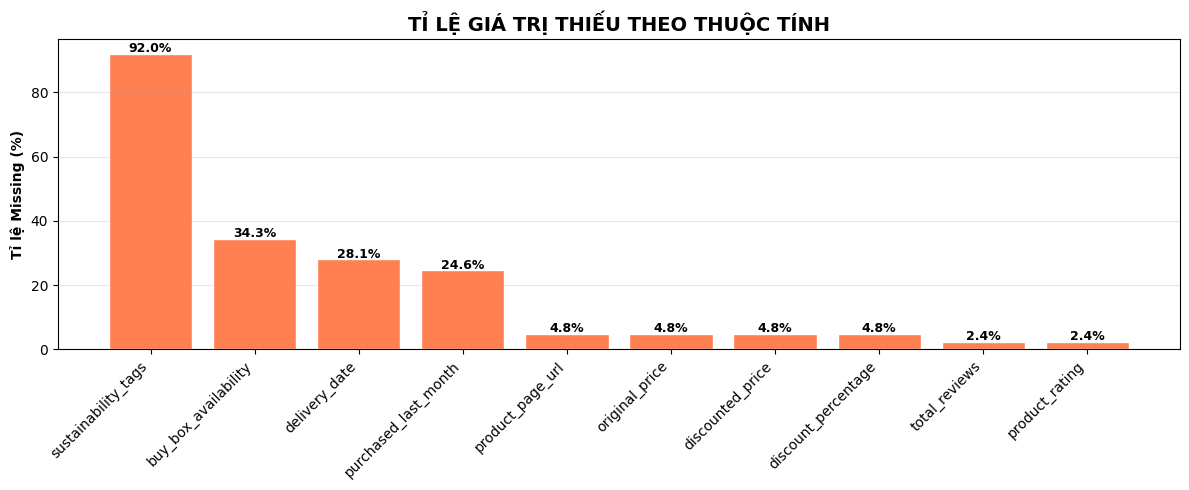

In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(missing_pct)), missing_pct.values, 
              color='coral', edgecolor='white')
ax.set_xticks(range(len(missing_pct)))
ax.set_xticklabels(missing_pct.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Tỉ lệ Missing (%)', fontweight='bold')
ax.set_title('TỈ LỆ GIÁ TRỊ THIẾU THEO THUỘC TÍNH', 
             fontweight='bold', fontsize=14)

for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


**Kiểm định giả thuyết MCAR bằng Little’s MCAR test**

In [26]:
def littles_mcar_test(data):
    missing_cols = data.columns[data.isnull().any()].tolist()

    data_subset = data[missing_cols].copy()
    n = len(data_subset)
    k = len(missing_cols)

    mask = data_subset.isnull().values
    patterns = pd.DataFrame(mask).groupby(list(range(k))).indices

    mu_grand = data_subset.mean().values
    sigma = data_subset.cov().values

    d2 = 0
    for pattern, indices in patterns.items():
        if len(indices) < 2: continue
        
        sub_data = data_subset.iloc[indices]
        observed_cols = [i for i, is_missing in enumerate(pattern) if not is_missing]
        
        if not observed_cols: continue
        
        mu_j = sub_data.iloc[:, observed_cols].mean().values
        mu_g_j = mu_grand[observed_cols]
        sigma_j = sigma[np.ix_(observed_cols, observed_cols)]
        
        try:
            diff = mu_j - mu_g_j
            inv_sigma_j = np.linalg.pinv(sigma_j)
            d2 += len(indices) * diff.dot(inv_sigma_j).dot(diff)
        except:
            continue

    df_degrees = k 
    p_value = stats.chi2.sf(d2, df_degrees)
    return d2, p_value 

chi2_stat, p_val_mcar = littles_mcar_test(numeric_df)
print(f"KẾT QUẢ KIỂM ĐỊNH LITTLE'S MCAR TEST:")
print(f"- Chi-square Statistic: {chi2_stat:.4f}")
print(f"- P-value: {p_val_mcar:.4e}")

KẾT QUẢ KIỂM ĐỊNH LITTLE'S MCAR TEST:
- Chi-square Statistic: 6519.5546
- P-value: 0.0000e+00


**5.4. Phân tích kết quả và đề xuất:**
Dựa trên sự kết hợp giữa trực quan hóa ma trận và kiểm định giả thuyết Little's MCAR, nhóm rút ra các nhận xét sau:

Biểu đồ tỉ lệ missing cho thấy 3 nhóm rõ rệt:
* **Nhóm thiếu nghiêm trọng (> 20%):** `sustainability_tags` (92.0%), 
  `buy_box_availability` (34.3%), `delivery_date` (28.1%), 
  `purchased_last_month` (24.6%) — đây là các thuộc tính không bắt buộc 
  trên sàn Amazon, phụ thuộc vào loại sản phẩm và chính sách người bán.

* **Nhóm thiếu nhẹ (≈ 4.8%):** `product_page_url`, `original_price`, 
  `discounted_price`, `discount_percentage` — tỉ lệ missing gần bằng nhau 
  (đều 4.8%) gợi ý các dòng này thiếu đồng thời, có thể do lỗi crawl 
  hoặc sản phẩm bị gỡ khỏi sàn.

* **Nhóm gần đầy đủ (≈ 2.4%):** `total_reviews`, `product_rating` — 
  chỉ thiếu ở sản phẩm mới chưa có đánh giá.
  
**Phân tích trực quan**
* **Tính hệ thống :** Quan sát ma trận cho thấy các dải trắng (giá trị thiếu) không xuất hiện rải rác mà tập trung theo từng cụm, đặc biệt là sự tương quan vị trí giữa các cột `product_rating`  và `total_reviews`. Điều này gợi ý rằng khi một sản phẩm thiếu dữ liệu về lượt mua, nó cũng thường thiếu luôn các thông tin về đánh giá.
* **Độ thưa đặc trưng:** Thuộc tính `sustainability_tags` có tỉ lệ khuyết cực cao (gần như trắng xóa), cho thấy đây là một đặc trưng hiếm (Sparse feature) trong tập dữ liệu Amazon, chỉ xuất hiện ở một số nhóm sản phẩm đặc thù.

**Kết quả kiểm định Little's MCAR**
* **Thống kê:** Chi-square Statistic = $6519.5546$; $p\text{-value} = 0.0000e+00$.
* **Kết luận:** Với mức ý nghĩa $\alpha = 0.05$, do $p\text{-value} < \alpha$, ta **bác bỏ giả thuyết $H_0$**. 
* **Ý nghĩa:** Tập dữ liệu **không phải cơ chế MCAR** (Thiếu hoàn toàn ngẫu nhiên). Sự thiếu hụt dữ liệu ở đây có quy luật và phụ thuộc vào các yếu tố khác.

**Phân loại cơ chế và Giải thích**
Dựa trên ngữ cảnh thực tế của sàn thương mại điện tử Amazon, nhóm phân loại cơ chế này là **MAR (Missing At Random)** kết hợp **MNAR (Missing Not At Random)**:
* **Giải thích:** Các sản phẩm mới được đăng tải hoặc các sản phẩm thuộc ngách thị trường ít người quan tâm thường sẽ không có lượt mua và đánh giá. Như vậy, việc "thiếu" dữ liệu ở đây phụ thuộc vào "độ tuổi" của sản phẩm trên sàn hoặc mức độ phổ biến của nó (biến quan sát được).
* **Ví dụ:** Cột `original_price` bị thiếu có thể do sản phẩm đó hiện không có chương trình giảm giá, nên giá gốc không được hệ thống hiển thị/ghi nhận.

**Đề xuất xử lý:** Vì dữ liệu không phải MCAR, nhóm tuyệt đối **không sử dụng phương pháp xóa dòng** để tránh làm mất đi toàn bộ nhóm "sản phẩm mới" hoặc "sản phẩm không khuyến mãi", gây lệch mẫu nghiêm trọng. Nhóm đề xuất sử dụng kỹ thuật **KNN Imputer** hoặc các phương pháp điền khuyết dựa trên phân phối của từng Category để khôi phục dữ liệu.

